# EC back-rotation with stats (non-rotated radius)

In [1]:
from dvr import *

## Back-rotated radius as phi varies
### EC trained on eigenvectors of CS Hamiltonian at 50 rotation angles in a range $\phi\in[\pi/24, \pi/6]$.
### $\langle r^2\rangle$ predicted at 20 points in $\phi\in[0.0,\pi/6]$. $r^2$ operator is not rotated.

In [2]:
# define system parameters
n = 256                      # number of DVR grid points
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

save_plots = True           # save plots or not

gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

In [3]:
# get exact data
phi_predict = np.linspace(0.0, pi/6, 20)

test_system = DVR(n, L, rotation_angle=pi/24, potential=gauss_s)
exact_energy, eigstate = test_system.closest_to_resonance(real_res)
exact_rr = test_system.compute_r2(eigstate[:, 0], rotate_rr=True, regulator=False)

# get training data and train EC
phi_train = np.linspace(pi/24, pi/6, 50) # np.random.uniform(pi/24, pi/6, 10)

test_EC = ECSystem(n, L, real_res, potential=gauss_s)
test_EC.train(phi_train)
test_EC.construct_basis()

train_rrs = test_EC.training_rrs

# use EC to predict energies and <r^2>
test, predict_rrs = test_EC.predict(phi_predict, rotate_rr=False)

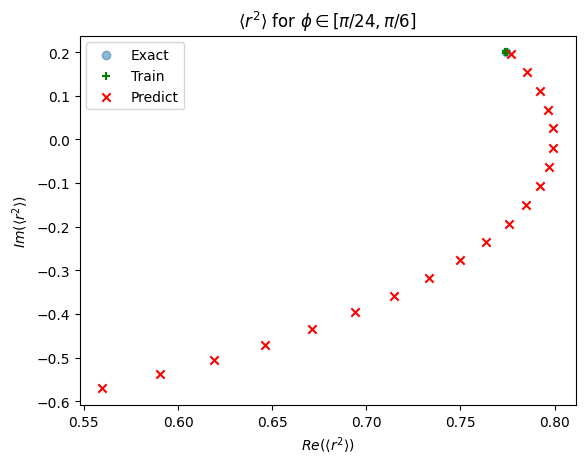

In [4]:
# plot rrs as phi changes
fig, ax = plt.subplots()
ax.scatter(np.real(exact_rr), np.imag(exact_rr), alpha=0.5, label="Exact")
ax.scatter(np.real(train_rrs), np.imag(train_rrs), c='green', marker='+', label="Train")
ax.scatter(np.real(predict_rrs), np.imag(predict_rrs), c='red', marker='x', label="Predict")
ax.set_xlabel(r"$Re(\langle r^2\rangle)$")
ax.set_ylabel(r"$Im(\langle r^2\rangle)$")
ax.legend()
ax.set_title(r"$\langle r^2\rangle$ for $\phi\in [\pi/24,\pi/6]$")
if save_plots:
    plt.savefig(f"./plots/ec_radius_defaultrr.png")
plt.show()

## Back-rotated radius with stats
### EC trained on eigenvectors of CS Hamiltonian at a rotation angle range $\phi\in [\pi/24, \pi/6]$.
### $\langle r^2 \rangle$ and energy predicted at $\phi=0$. $r^2$ is not rotated.
### We plot the median and quartile predictions of 128 EC systems trained on random points in the range above for 3, 5, 10, 20, 40, and 50 training points.

In [5]:
import random

In [6]:
seed = 1

random.seed(seed)
np.random.seed(seed)

In [7]:
n_ecsystems = 128
# all other parameters already defined above

In [8]:
# exact_energy, exact_rr already computed above

# compute training data
phi_training_range, num_phi_points_list = [pi/24, pi/6], [3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# get training region for plotting purposes
test_system = DVR(n, L, rotation_angle=pi/24, potential=gauss_s)
train_energies, train_rrs = [], []
for phi in np.linspace(phi_training_range[0], phi_training_range[1], 25):
    test_system.reset_rotation_angle(phi)
    eigval, eigstate = test_system.closest_to_resonance(real_res)
    rr = test_system.compute_r2(eigstate[:, 0], rotate_rr=True)
    train_energies.append(eigval[0])
    train_rrs.append(rr)

In [9]:
# construct EC ensemble and train all ECs
EC_ensemble = ECEnsemble(n_ecsystems, n, L, real_res, potential=gauss_s)
predict_energies, predict_rrs = [], []
predict_rrs_err95, predict_rrs_err68 = [], []
predict_energies_err95, predict_energies_err68 = [], []
for num_phi_points in num_phi_points_list:
    print(f"Training with {num_phi_points}")
    EC_ensemble.train(phi_training_range, num_phi_points)
    EC_ensemble.construct_bases()

    # predict at phi=0.0
    extrapolated_energies, extrapolated_rrs, \
        extrapolated_rrs_err95, extrapolated_rrs_err68, \
        extrapolated_energies_err95, extrapolated_energies_err68 = EC_ensemble.extrapolate([0.0], rotate_rr=False)

    predict_energies.append(extrapolated_energies[0])
    predict_rrs.append(extrapolated_rrs[0])
    predict_rrs_err95.append(extrapolated_rrs_err95[:, 0])
    predict_rrs_err68.append(extrapolated_rrs_err68[:, 0])
    predict_energies_err95.append(extrapolated_energies_err95[:, 0])
    predict_energies_err68.append(extrapolated_energies_err68[:, 0])
    
    EC_ensemble.clear_all()

predict_rrs_err95 = np.array(predict_rrs_err95).T
predict_rrs_err68 = np.array(predict_rrs_err68).T
predict_energies_err95 = np.array(predict_energies_err95).T
predict_energies_err68 = np.array(predict_energies_err68).T

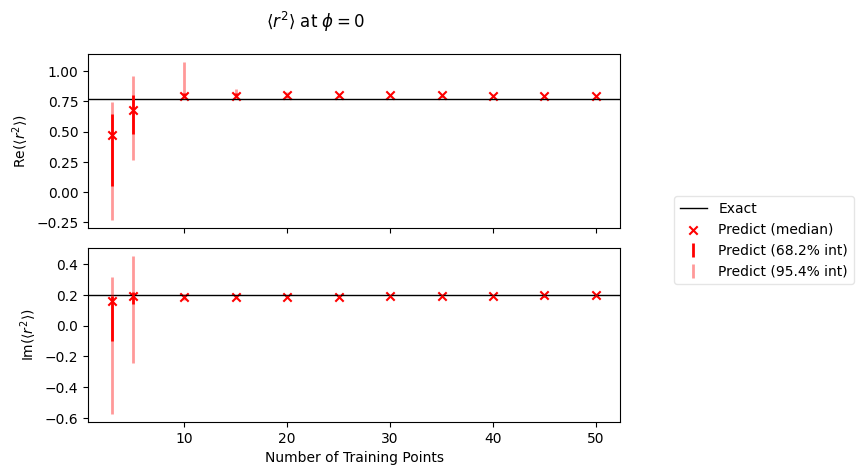

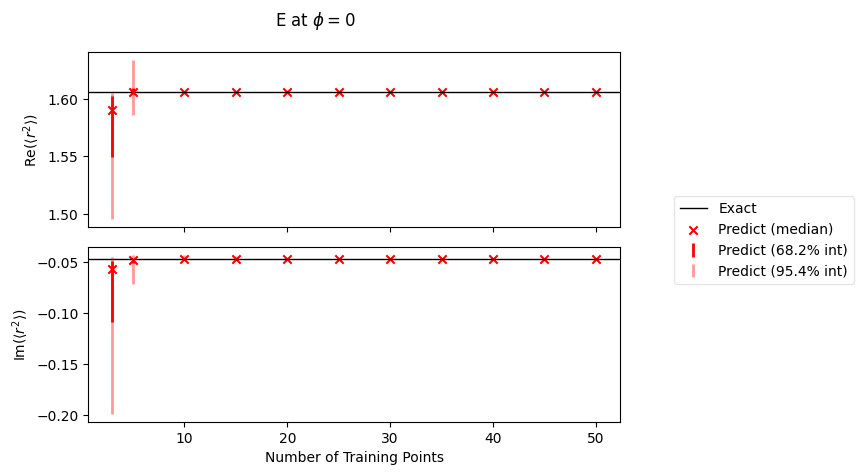

In [10]:
# RADIUS PLOT
# plot results with error bands
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
# real-component
ax1.axhline(y=np.real(exact_rr), color='black', linewidth=1.0, linestyle='-', label='Exact')
#ax1.axhspan(ymin=np.min(np.real(train_rrs)), ymax=np.max(np.real(train_rrs)), color='gray', alpha=1.0, label='Train')
ax1.scatter(num_phi_points_list, np.real(predict_rrs), c='red', marker='x', label='Predict (median)')
ax1.errorbar(num_phi_points_list, np.real(predict_rrs),
             yerr=(np.real(predict_rrs_err68[0]), np.real(predict_rrs_err68[1])),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
ax1.errorbar(num_phi_points_list, np.real(predict_rrs),
             yerr=(np.real(predict_rrs_err95[0]), np.real(predict_rrs_err95[1])),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=0.4, label='Predict (95.4% int)')
ax1.set_ylabel(r"Re($\langle r^2\rangle)$")

# imag component
ax2.axhline(y=np.imag(exact_rr), color='black', linewidth=1.0, linestyle='-', label='Exact')
#ax2.axhspan(ymin=np.min(np.imag(train_rrs)), ymax=np.max(np.imag(train_rrs)), color='gray', alpha=1.0) 
ax2.scatter(num_phi_points_list, np.imag(predict_rrs), c='red', marker='x', label='Predict (median)')
ax2.errorbar(num_phi_points_list, np.imag(predict_rrs),
             yerr=(np.imag(predict_rrs_err68[0]), np.imag(predict_rrs_err68[1])),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
ax2.errorbar(num_phi_points_list, np.imag(predict_rrs),
             yerr=(np.imag(predict_rrs_err95[0]), np.imag(predict_rrs_err95[1])),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=0.4, label='Predict (95.4% int)')
ax2.set_ylabel(r"Im($\langle r^2\rangle)$")

ax2.set_xlabel("Number of Training Points")
fig.suptitle(r"$\langle r^2 \rangle$ at $\phi=0$")
# set legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.05, 0.5), framealpha=0.5)
ax1.legend().remove()
ax2.legend().remove()
plt.tight_layout()
if save_plots:
    plt.savefig(f"./plots/ec_radius_defaultrr_vartrainstats.png")
plt.show()

#------------------------------------------------------------------------------------------------------
# ENERGY PLOT
# plot results with error bands
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
# real-component
ax1.axhline(y=np.real(exact_energy), color='black', linewidth=1.0, linestyle='-', label='Exact')
#ax1.axhspan(ymin=np.min(np.real(train_energies)), ymax=np.max(np.real(train_energies)), color='gray', alpha=1.0, label='Train')
ax1.scatter(num_phi_points_list, np.real(predict_energies), c='red', marker='x', label='Predict (median)')
ax1.errorbar(num_phi_points_list, np.real(predict_energies),
             yerr=(np.real(predict_energies_err68[0]), np.real(predict_energies_err68[1])),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
ax1.errorbar(num_phi_points_list, np.real(predict_energies),
             yerr=(np.real(predict_energies_err95[0]), np.real(predict_energies_err95[1])),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=0.4, label='Predict (95.4% int)')
ax1.set_ylabel(r"Re($\langle r^2\rangle)$")
# imag component
ax2.axhline(y=np.imag(exact_energy), color='black', linewidth=1.0, linestyle='-', label='Exact')
#ax2.axhspan(ymin=np.min(np.imag(train_energies)), ymax=np.max(np.imag(train_energies)), color='gray', alpha=1.) 
ax2.scatter(num_phi_points_list, np.imag(predict_energies), c='red', marker='x', label='Predict (median)')
ax2.errorbar(num_phi_points_list, np.imag(predict_energies),
             yerr=(np.imag(predict_energies_err68[0]), np.imag(predict_energies_err68[1])),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
ax2.errorbar(num_phi_points_list, np.imag(predict_energies),
             yerr=(np.imag(predict_energies_err95[0]), np.imag(predict_energies_err95[1])),
             fmt='none', ecolor='red', elinewidth=2.0, alpha=0.4, label='Predict (95.4% int)')
ax2.set_ylabel(r"Im($\langle r^2\rangle)$")
ax2.set_xlabel("Number of Training Points")
fig.suptitle(r"E at $\phi=0$")
# set legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.05, 0.5), framealpha=0.5)
ax1.legend().remove()
ax2.legend().remove()
plt.tight_layout()
if save_plots:
    plt.savefig(f"./plots/ec_E_vartrainstats.png")
plt.show()